<a href="https://colab.research.google.com/github/adljna/Blu-SentimentAnalysis/blob/main/Feature%20Engineering/5-Exploration-BoW-TFIDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Text Exploration — Bag of Words & TF-IDF
## Blu App Review · Sentiment Analysis

---

Notebook ini melakukan **eksplorasi teks** dari review aplikasi blu by BCA Digital menggunakan dua pendekatan representasi teks: **Bag of Words (BoW)** dan **TF-IDF**.

> ⚠️ **Notebook ini murni eksplorasi & visualisasi.**  
> Fitur untuk modeling diproduksi secara terpisah di `5b-FeatureEngineering-ForModeling.ipynb`.

### Apa yang dilakukan di notebook ini?

| # | Tahap | Metode | Tujuan |
|---|---|---|---|
| 1 | Setup | — | Import library, load data |
| 2 | Frekuensi Manual | Counter | Lihat vocab & distribusi kata global |
| 3 | Bag of Words | CountVectorizer | Representasi frekuensi kata mentah |
| 4 | TF-IDF | TfidfVectorizer | Representasi bobot kata yang lebih cerdas |
| 5 | Analisis N-gram | Bigram & Trigram | Temukan frasa berulang |
| 6 | Perbandingan BoW vs TF-IDF | Side-by-side | Lihat perbedaan ranking kata |
| 7 | Word Cloud | WordCloud | Visualisasi per sentimen |
| 8 | Regex Insight | re | Kategorisasi keluhan & pujian |

### Alur pipeline keseluruhan
```
Scraping → Preprocessing → [ Notebook ini: Eksplorasi ] → 5b: Feature Eng → Modeling
```

---
## (1) Setup & Import Library

In [1]:
import os
import re
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud

os.makedirs('../data/visualisasi', exist_ok=True)
sns.set_theme(style='white')
plt.rcParams['figure.dpi'] = 120

print('✅ Library siap!')

✅ Library siap!


---
## (2) Load Data

Load hasil preprocessing yang sudah berisi kolom `final_content` (teks bersih) dan `sentiment_label`.

In [3]:
FILE_PATH  = '../data/bluapp_reviews_labeled_binary.csv'
TEXT_COL   = 'final_content'    # teks bersih hasil preprocessing
TOKEN_COL  = 'tokens_stemmed'   # kolom token (untuk frekuensi manual)
LABEL_COL  = 'sentiment'  # kolom label sentimen
RAW_COL    = 'content'          # teks asli (untuk regex)

df_bluRev = pd.read_csv(FILE_PATH)

print(f'Data dimuat: {df_bluRev.shape[0]:,} review, {df_bluRev.shape[1]} kolom')
print(f'Kolom: {df_bluRev.columns.tolist()}')
print()
print('Distribusi sentimen:')
print(df_bluRev[LABEL_COL].value_counts())
df_bluRev.head(3)

Data dimuat: 24,533 review, 16 kolom
Kolom: ['content', 'score', 'at', 'thumbsUpCount', 'replyContent', 'final_content', 'tokens_stemmed', 'sentiment', 'label_method', 'label_reason', 'word_count', 'pos_count', 'neg_count', 'net_score', 'text_label', 'rating_label']

Distribusi sentimen:
sentiment
positif    16857
negatif     7676
Name: count, dtype: int64


,content,score,at,thumbsUpCount,replyContent,final_content,tokens_stemmed,sentiment,label_method,label_reason,word_count,pos_count,neg_count,net_score,text_label,rating_label
0,"verifikasi wajah tidak jelas,stuck di pastikan...",1,2026-05-16 23:08:41,0,"Hai, Kak Darma. Maaf atas ketidaknyamanannya. ...",verifikasi wajah jelastuck pasti hp gerak hp t...,"['verifikasi', 'wajah', 'jelastuck', 'pasti', ...",negatif,rating,rating_ekstrem_rendah,10,0,0,0,netral,negatif
1,hihihihi kog ngeri nian baca review penggunany...,1,2026-05-16 22:10:32,0,"Hai, Kak Maulana. Maaf atas ketidaknyamanannya...",hihihihi kog ngeri nian baca review guna horor...,"['hihihihi', 'kog', 'ngeri', 'nian', 'baca', '...",negatif,rating,rating_ekstrem_rendah,14,0,0,0,netral,negatif
2,gak perlu di instal hanya menghabiskan paket d...,1,2026-05-16 21:52:46,0,"Hai, Kak Jaki. Maaf atas ketidaknyamanannya. K...",instal habis paket data cuk,"['instal', 'habis', 'paket', 'data', 'cuk']",negatif,rating,rating_ekstrem_rendah,5,0,0,0,netral,negatif


---
## (3) Frekuensi Kata Manual

Sebelum masuk ke vectorizer, kita hitung frekuensi kata secara manual dari kolom `tokens_stemmed`. Ini memberikan gambaran distribusi vocab mentah tanpa batasan `max_features`.

In [4]:
# Parse tokens dari string representasi list
tokens_list = []
for item in df_bluRev[TOKEN_COL].dropna():
    try:
        parsed = ast.literal_eval(item)
        if isinstance(parsed, list):
            tokens_list.append(parsed)
    except (ValueError, SyntaxError):
        pass

vocabulary   = [token for sublist in tokens_list for token in sublist]
word_freq    = Counter(vocabulary)
sorted_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)

# Mapping kata → ID (berdasarkan rank frekuensi)
word_to_number = {word: i+1 for i, (word, _) in enumerate(sorted_words)}

print(f'Total token unik (vocab)    : {len(word_freq):,}')
print(f'Total token keseluruhan     : {len(vocabulary):,}')
print()
print('Top 20 kata terbanyak:')
for word, count in sorted_words[:20]:
    bar = '█' * int(count / sorted_words[0][1] * 25)
    print(f'  {word:<20} {bar} {count:,}')

Total token unik (vocab)    : 13,042
Total token keseluruhan     : 160,922

Top 20 kata terbanyak:
  bagus                █████████████████████████ 6,074
  banget               ████████████ 3,031
  mudah                █████████ 2,423
  masuk                █████████ 2,242
  pakai                █████████ 2,234
  transaksi            ████████ 2,022
  buka                 █████ 1,433
  bantu                █████ 1,352
  transfer             █████ 1,319
  lambat               █████ 1,297
  daftar               █████ 1,239
  tolong               ████ 1,166
  rekening             ████ 1,145
  aplikasi             ████ 1,078
  biaya                ████ 1,056
  baik                 ████ 1,033
  kasih                ████ 987
  susah                ████ 984
  ok                   ███ 971
  cepat                ███ 963


---
## (4) Bag of Words (BoW)

**Bag of Words** merepresentasikan teks sebagai vektor frekuensi kata — setiap kata dihitung kemunculannya tanpa mempertimbangkan urutan atau konteks.

**Keterbatasan BoW:**
- Kata yang sering muncul di semua dokumen (seperti "aplikasi") mendapat bobot tinggi, padahal tidak informatif
- Tidak membedakan kata yang *umum* vs kata yang *diskriminatif*

→ Keterbatasan inilah yang coba diatasi oleh TF-IDF di section berikutnya.

In [5]:
vectorizer_bow = CountVectorizer(
    max_features = 1000,   # 1000 kata terbanyak
    ngram_range  = (1, 2), # unigram + bigram
    min_df       = 5,      # muncul minimal di 5 dokumen
    max_df       = 0.8     # buang kata yang ada di > 80% dokumen
)

X_bow          = vectorizer_bow.fit_transform(df_bluRev[TEXT_COL].astype(str))
bow_features   = vectorizer_bow.get_feature_names_out()
bow_counts     = np.sum(X_bow.toarray(), axis=0)

df_bow_freq = pd.DataFrame({
    'word'     : bow_features,
    'id'       : pd.array([word_to_number.get(w, None) for w in bow_features], dtype='Int64'),
    'bow_freq' : bow_counts
}).sort_values('bow_freq', ascending=False)

print(f'BoW matrix shape: {X_bow.shape}  (n_dokumen × n_fitur)')
print()
print('Top 20 kata (BoW):')
display(df_bow_freq.head(20).reset_index(drop=True))

BoW matrix shape: (24533, 1000)  (n_dokumen × n_fitur)

Top 20 kata (BoW):


,word,id,bow_freq
0,bagus,1,6074
1,banget,2,3031
2,mudah,3,2423
3,masuk,4,2242
4,pakai,5,2234
5,transaksi,6,2022
6,buka,7,1433
7,bantu,8,1352
8,transfer,9,1319
9,lambat,10,1297


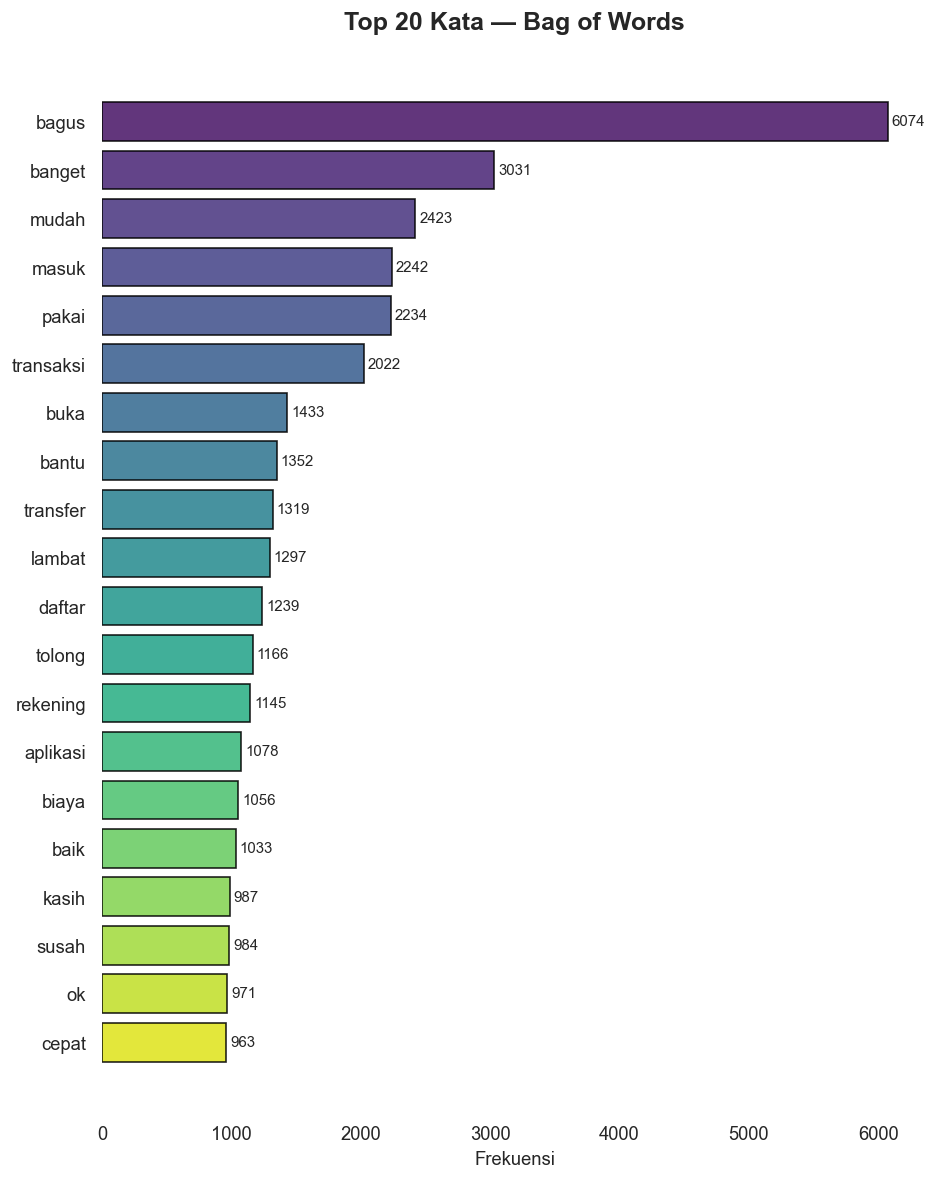

In [6]:
# Visualisasi top 20 kata BoW
top20_bow = df_bow_freq.head(20)
colors    = sns.color_palette('viridis', n_colors=20)

plt.figure(figsize=(8, 10))
bars = plt.barh(top20_bow['word'], top20_bow['bow_freq'],
                color=colors, edgecolor='black', alpha=0.85)
plt.gca().invert_yaxis()
plt.title('Top 20 Kata — Bag of Words', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Frekuensi', fontsize=11)
for i, v in enumerate(top20_bow['bow_freq']):
    plt.text(v + 30, i, str(int(v)), va='center', fontsize=9)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('../data/visualisasi/bow_top20.png', dpi=150, bbox_inches='tight')
plt.show()

---
## (5) TF-IDF — Eksplorasi

**TF-IDF** (Term Frequency–Inverse Document Frequency) memberikan bobot lebih tinggi pada kata yang:
- **Sering muncul** di satu dokumen (TF tinggi), tapi
- **Jarang muncul** di dokumen lain (IDF tinggi)

Hasilnya, kata-kata generik seperti "aplikasi" atau "dan" yang ada di hampir semua review mendapat bobot rendah secara otomatis — tanpa perlu dihapus manual.

In [7]:
vectorizer_tfidf = TfidfVectorizer(
    max_features = 1000,   # sama dengan BoW untuk perbandingan adil
    ngram_range  = (1, 2),
    min_df       = 5,
    max_df       = 0.8
)

X_tfidf        = vectorizer_tfidf.fit_transform(df_bluRev[TEXT_COL].astype(str))
tfidf_features = vectorizer_tfidf.get_feature_names_out()
tfidf_avg      = np.mean(X_tfidf.toarray(), axis=0)  # rata-rata skor TF-IDF per kata

df_tfidf_freq = pd.DataFrame({
    'word'      : tfidf_features,
    'tfidf_avg' : tfidf_avg
}).sort_values('tfidf_avg', ascending=False)

print(f'TF-IDF matrix shape: {X_tfidf.shape}')
print()
print('Top 20 kata (TF-IDF rata-rata):')
display(df_tfidf_freq.head(20).reset_index(drop=True))

TF-IDF matrix shape: (24533, 1000)

Top 20 kata (TF-IDF rata-rata):


,word,tfidf_avg
0,bagus,0.112935
1,mudah,0.031954
2,ok,0.029466
3,banget,0.028264
4,bantu,0.025933
5,god,0.025613
6,transaksi,0.020637
7,masuk,0.019929
8,pakai,0.018854
9,lambat,0.016012


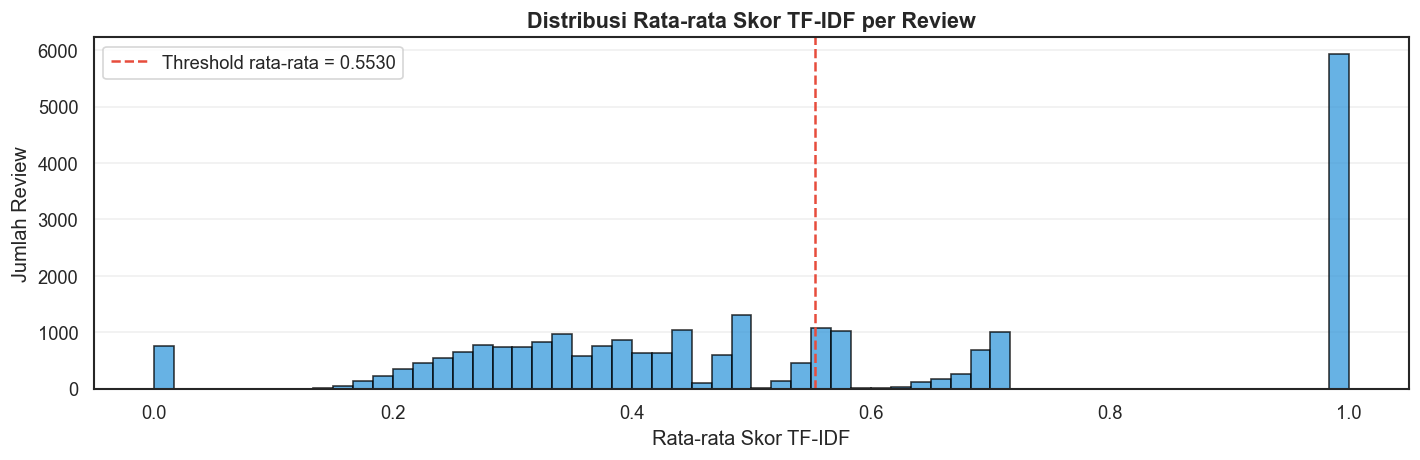

Threshold (rata-rata semua skor): 0.5530
Review di atas threshold        : 10,153


In [8]:
# Distribusi rata-rata skor TF-IDF per kalimat
sent_scores = []
for i in range(X_tfidf.shape[0]):
    row = X_tfidf[i]
    nnz = row.nnz
    sent_scores.append(row.sum() / nnz if nnz > 0 else 0)

threshold = np.mean(sent_scores)

plt.figure(figsize=(12, 4))
plt.hist(sent_scores, bins=60, edgecolor='black', alpha=0.75, color='#3498DB')
plt.axvline(threshold, color='#E74C3C', linestyle='--', linewidth=1.5,
            label=f'Threshold rata-rata = {threshold:.4f}')
plt.title('Distribusi Rata-rata Skor TF-IDF per Review', fontsize=13, fontweight='bold')
plt.xlabel('Rata-rata Skor TF-IDF')
plt.ylabel('Jumlah Review')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/visualisasi/tfidf_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Threshold (rata-rata semua skor): {threshold:.4f}')
print(f'Review di atas threshold        : {sum(s >= threshold for s in sent_scores):,}')

---
## (6) Analisis N-gram — Bigram & Trigram

N-gram menangkap frasa multi-kata yang tidak terlihat dari analisis kata tunggal. Misalnya "tidak bisa" lebih informatif daripada "tidak" dan "bisa" secara terpisah.

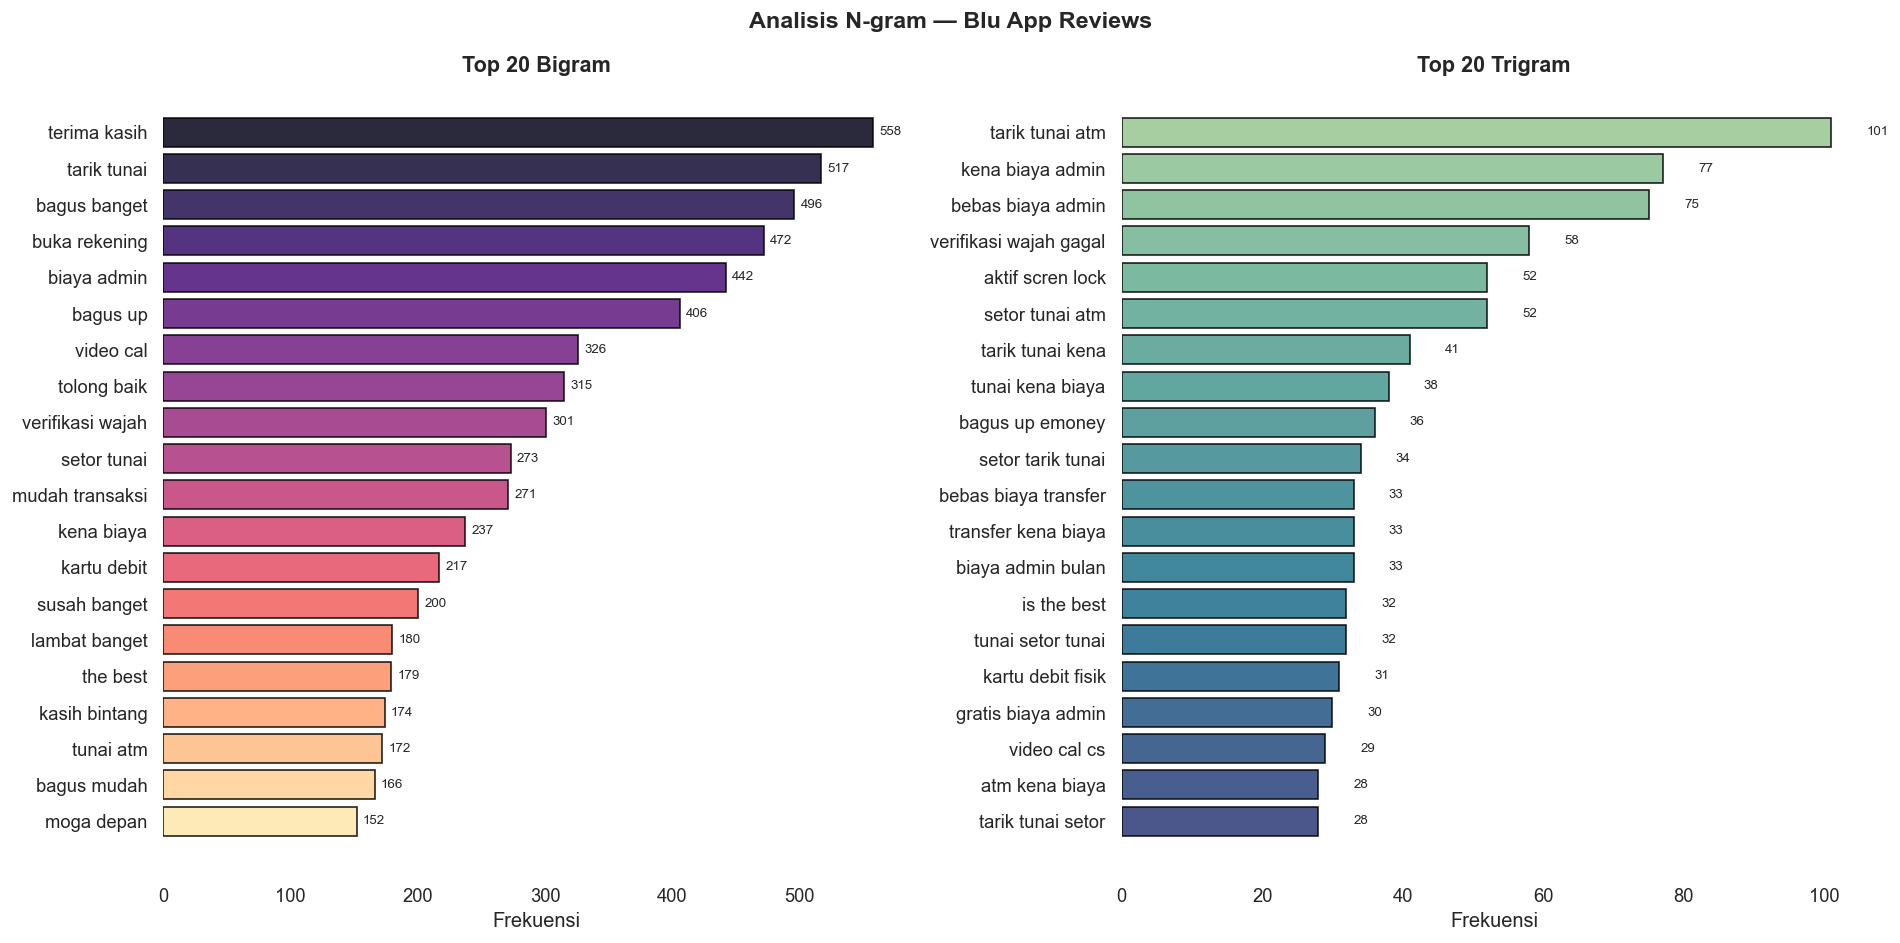

In [9]:
def get_top_ngrams(corpus, ngram_range, top_n=20, min_df=5):
    """Ekstrak top N n-gram berdasarkan frekuensi."""
    vec = CountVectorizer(ngram_range=ngram_range, min_df=min_df, max_features=200)
    X   = vec.fit_transform(corpus)
    freqs = np.sum(X.toarray(), axis=0)
    return pd.DataFrame({
        'ngram'    : vec.get_feature_names_out(),
        'frequency': freqs
    }).sort_values('frequency', ascending=False).head(top_n)

corpus = df_bluRev[TEXT_COL].astype(str)

df_bigram  = get_top_ngrams(corpus, (2, 2), top_n=20)
df_trigram = get_top_ngrams(corpus, (3, 3), top_n=20)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, df_ng, title, palette in zip(
    axes,
    [df_bigram, df_trigram],
    ['Top 20 Bigram', 'Top 20 Trigram'],
    ['magma', 'crest']
):
    colors = sns.color_palette(palette, n_colors=20)
    ax.barh(df_ng['ngram'], df_ng['frequency'],
            color=colors, edgecolor='black', alpha=0.85)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Frekuensi')
    for i, v in enumerate(df_ng['frequency']):
        ax.text(v + 5, i, str(int(v)), va='center', fontsize=8)
    sns.despine(ax=ax, left=True, bottom=True)

plt.suptitle('Analisis N-gram — Blu App Reviews', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/visualisasi/ngram_bigram_trigram.png', dpi=150, bbox_inches='tight')
plt.show()

---
## (7) Perbandingan BoW vs TF-IDF

Ini inti dari menggabungkan dua notebook ini — melihat **perbedaan ranking kata** antara BoW dan TF-IDF.

Kata yang rankingnya **naik di TF-IDF** → kata yang benar-benar diskriminatif (unik di sebagian review saja).  
Kata yang rankingnya **turun di TF-IDF** → kata generik yang tersebar merata di semua review.

In [10]:
# Gabungkan ranking BoW dan TF-IDF
df_bow_ranked   = df_bow_freq[['word', 'bow_freq']].reset_index(drop=True)
df_bow_ranked['bow_rank'] = df_bow_ranked.index + 1

df_tfidf_ranked = df_tfidf_freq[['word', 'tfidf_avg']].reset_index(drop=True)
df_tfidf_ranked['tfidf_rank'] = df_tfidf_ranked.index + 1

df_compare = df_bow_ranked.merge(df_tfidf_ranked, on='word', how='inner')
df_compare['rank_diff'] = df_compare['bow_rank'] - df_compare['tfidf_rank']
# rank_diff positif → naik ranking di TF-IDF (lebih penting)
# rank_diff negatif → turun ranking di TF-IDF (lebih generik)

print('Kata yang NAIK ranking di TF-IDF (lebih diskriminatif dari yang dikira BoW):')
display(df_compare.sort_values('rank_diff', ascending=False).head(10)[['word','bow_rank','tfidf_rank','rank_diff']].reset_index(drop=True))

print()
print('Kata yang TURUN ranking di TF-IDF (ternyata lebih generik):')
display(df_compare.sort_values('rank_diff', ascending=True).head(10)[['word','bow_rank','tfidf_rank','rank_diff']].reset_index(drop=True))

Kata yang NAIK ranking di TF-IDF (lebih diskriminatif dari yang dikira BoW):


,word,bow_rank,tfidf_rank,rank_diff
0,mntap,879,377,502
1,mantab,791,378,413
2,sangat,988,588,400
3,bgus,892,497,395
4,ok bagus,718,395,323
5,mudah bantu,868,565,303
6,bagus simple,943,644,299
7,very,705,420,285
8,bagus dah,808,526,282
9,mudah ribet,996,734,262



Kata yang TURUN ranking di TF-IDF (ternyata lebih generik):


,word,bow_rank,tfidf_rank,rank_diff
0,mesin,554,791,-237
1,hadap,714,943,-229
2,wa,666,881,-215
3,masuk rekening,617,824,-207
4,mesin atm,782,984,-202
5,tlp,656,857,-201
6,kanan,766,963,-197
7,nominal,516,707,-191
8,ulas,678,863,-185
9,gtu,764,947,-183


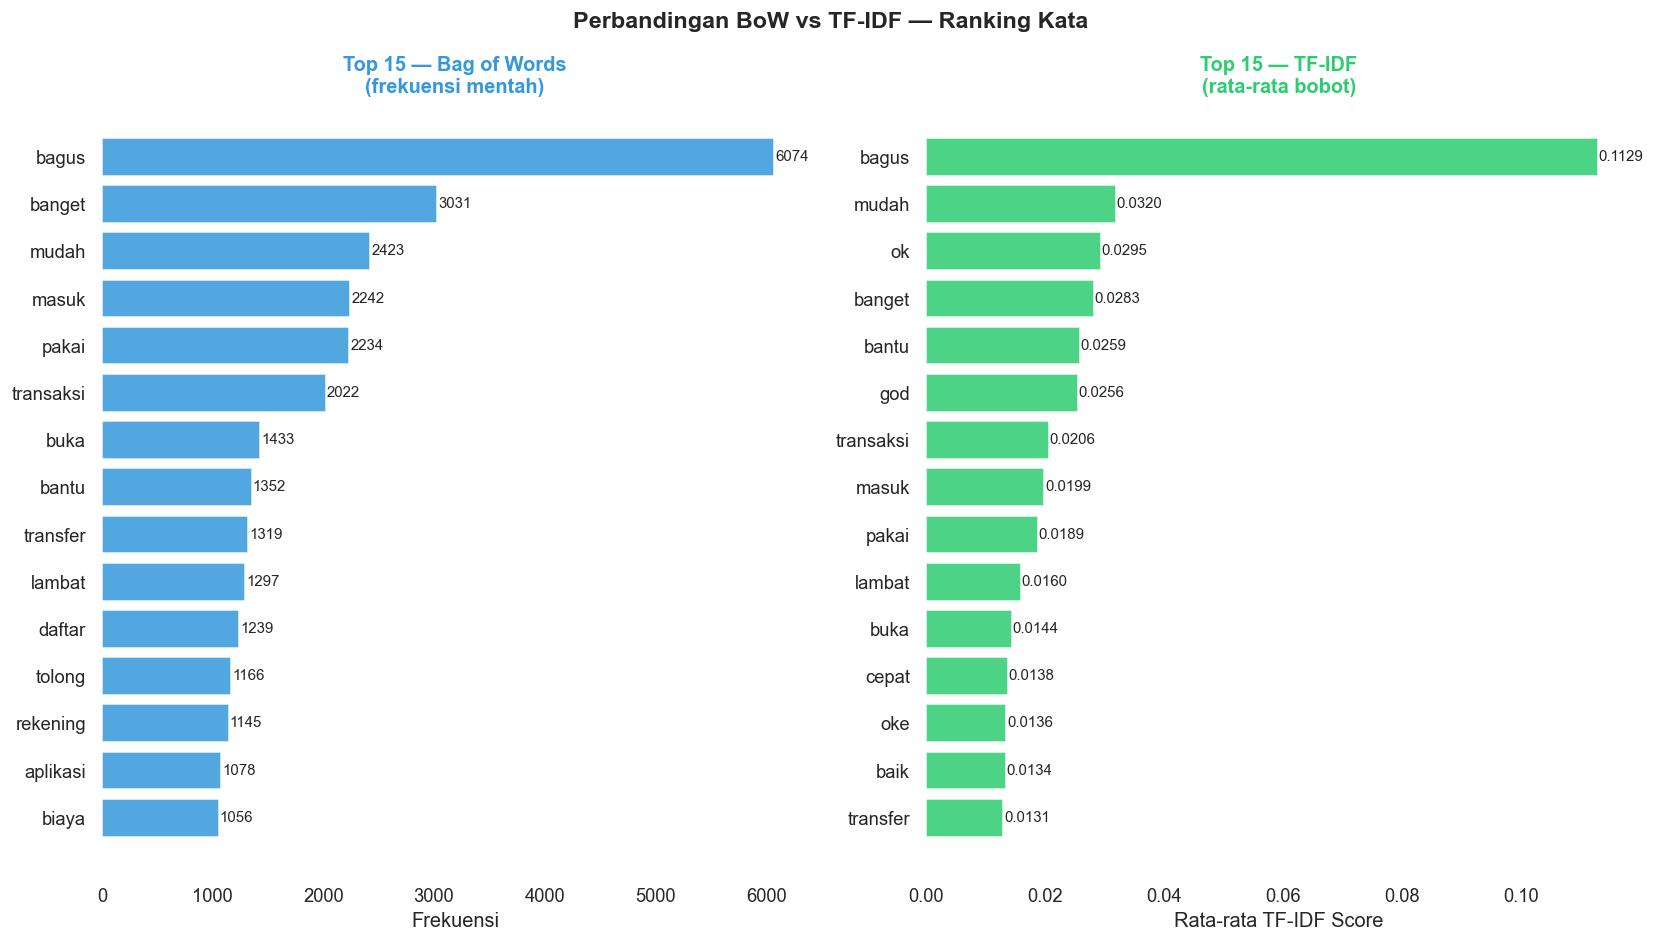

In [11]:
# Visualisasi side-by-side top 15 BoW vs TF-IDF
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# BoW
top15_bow = df_bow_freq.head(15)
axes[0].barh(top15_bow['word'], top15_bow['bow_freq'],
             color='#3498DB', alpha=0.85, edgecolor='white')
axes[0].invert_yaxis()
axes[0].set_title('Top 15 — Bag of Words\n(frekuensi mentah)',
                  fontweight='bold', color='#3498DB')
axes[0].set_xlabel('Frekuensi')
for i, v in enumerate(top15_bow['bow_freq']):
    axes[0].text(v + 10, i, str(int(v)), va='center', fontsize=9)

# TF-IDF
top15_tfidf = df_tfidf_freq.head(15)
axes[1].barh(top15_tfidf['word'], top15_tfidf['tfidf_avg'],
             color='#2ECC71', alpha=0.85, edgecolor='white')
axes[1].invert_yaxis()
axes[1].set_title('Top 15 — TF-IDF\n(rata-rata bobot)',
                  fontweight='bold', color='#2ECC71')
axes[1].set_xlabel('Rata-rata TF-IDF Score')
for i, v in enumerate(top15_tfidf['tfidf_avg']):
    axes[1].text(v + 0.0001, i, f'{v:.4f}', va='center', fontsize=9)

for ax in axes:
    sns.despine(ax=ax, left=True, bottom=True)

plt.suptitle('Perbandingan BoW vs TF-IDF — Ranking Kata',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/visualisasi/bow_vs_tfidf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## (8) Word Cloud per Sentimen

Word cloud menggunakan bobot TF-IDF (bukan frekuensi mentah) supaya kata yang tampil benar-benar mewakili tiap kelas sentimen, bukan kata generik yang ada di mana-mana.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24500\1965174078.py:37: UserWarning: Glyph 9729 (\N{CLOUD}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24500\1965174078.py:37: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24500\1965174078.py:38: UserWarning: Glyph 9729 (\N{CLOUD}) missing from font(s) Arial.
  plt.savefig('../data/visualisasi/wordcloud_per_sentimen.png', dpi=150, bbox_inches='tight')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24500\1965174078.py:38: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.savefig('../data/visualisasi/wordcloud_per_sentimen.png', dpi=150, bbox_inches='tight')
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9729 (\N{CLOU

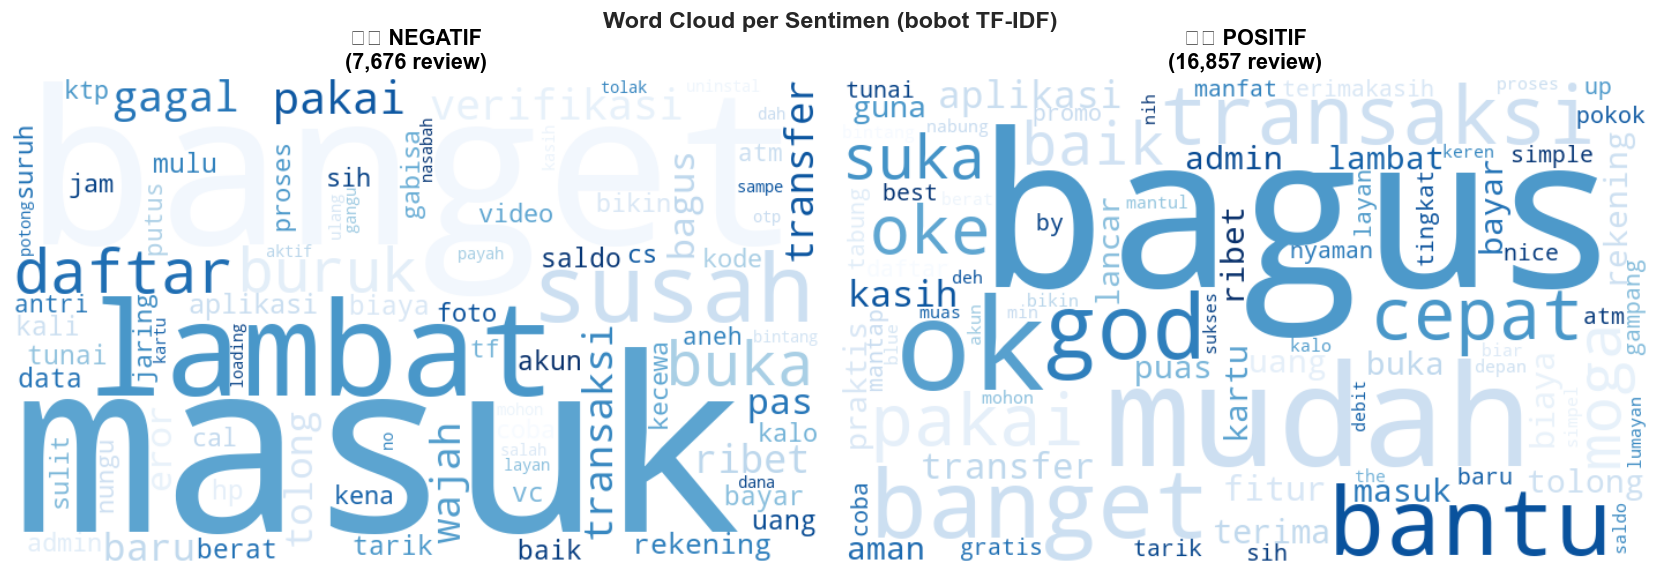

In [12]:
COLORS_SENT = {'positive': '#2ECC71', 'negative': '#E74C3C', 'neutral': '#F39C12'}
CMAP_SENT   = {'positive': 'Greens',  'negative': 'Reds',    'neutral': 'Oranges'}

labels = df_bluRev[LABEL_COL].dropna().unique().tolist()
fig, axes = plt.subplots(1, len(labels), figsize=(7*len(labels), 5))
if len(labels) == 1: axes = [axes]

for ax, label in zip(axes, labels):
    subset = df_bluRev[df_bluRev[LABEL_COL] == label][TEXT_COL].astype(str)
    text   = ' '.join(subset.tolist())

    # Pakai TF-IDF scores sebagai bobot word cloud
    vec_wc  = TfidfVectorizer(max_features=200, ngram_range=(1,1))
    X_wc    = vec_wc.fit_transform(subset)
    scores  = dict(zip(
        vec_wc.get_feature_names_out(),
        np.mean(X_wc.toarray(), axis=0)
    ))

    wc = WordCloud(
        width=700, height=420,
        background_color='white',
        colormap=CMAP_SENT.get(label, 'Blues'),
        max_words=80,
        collocations=False,
        random_state=42
    ).generate_from_frequencies(scores)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'☁️ {label.upper()}\n({len(subset):,} review)',
                 fontweight='bold',
                 color=COLORS_SENT.get(label, 'black'),
                 fontsize=13)

plt.suptitle('Word Cloud per Sentimen (bobot TF-IDF)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/visualisasi/wordcloud_per_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()

---
## (9) Export Hasil Eksplorasi

In [16]:
# Simpan tabel frekuensi dan insight
df_bow_freq.to_csv('../data/bow_word_frequencies.csv', index=False)
df_tfidf_freq.to_csv('../data/tfidf_word_scores.csv', index=False)
df_bigram.to_csv('../data/bigram_frequencies.csv', index=False)
df_trigram.to_csv('../data/trigram_frequencies.csv', index=False)
df_compare.to_csv('../data/bow_vs_tfidf_comparison.csv', index=False)
insight_counts.to_csv('../data/regex_insight_counts.csv', index=True)

print('✅ File eksplorasi disimpan:')
print('   bow_word_frequencies.csv')
print('   tfidf_word_scores.csv')
print('   bigram_frequencies.csv')
print('   trigram_frequencies.csv')
print('   bow_vs_tfidf_comparison.csv')
print('   regex_insight_counts.csv')
print()
print('Gambar disimpan di: ../data/visualisasi/')
print()
print('─'*50)
print('Langkah berikutnya:')
print('  → 5b-FeatureEngineering-ForModeling.ipynb')
print('─'*50)

✅ File eksplorasi disimpan:
   bow_word_frequencies.csv
   tfidf_word_scores.csv
   bigram_frequencies.csv
   trigram_frequencies.csv
   bow_vs_tfidf_comparison.csv
   regex_insight_counts.csv

Gambar disimpan di: ../data/visualisasi/

──────────────────────────────────────────────────
Langkah berikutnya:
  → 5b-FeatureEngineering-ForModeling.ipynb
──────────────────────────────────────────────────
